In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Data Preparation
#The dataset is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. 
#The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD). 
#The dataset provides the patients information. It includes over 4,000 records and 15 attributes.
#Loading and Handling Missing Values from the Dataset
#We will load the dataset and drop the irrelevant features from the the dataset like "education" and rename columns also.
#disease_df.pd.read_csv(): This is used to read the contents of CSV file.
#disease_df, dropna(axis=0, inplace=True): This removes any rows with missing values (NaN) from the DataFrame.
#disease_df.TenYearCHD.value_counts(): This prints the count of unique values in the TenYearCHD column which likely indicates whether a patient has heart
#disease.
disease_df = pd.read_csv(r"C:\Users\KIIT\Downloads\framingham (1).csv")
disease_df.drop(columns=['education'], inplace = True, axis = 1)
disease_df.rename(columns ={'male':'Sex_male'}, inplace = True)
disease_df.dropna(axis = 0, inplace = True)
disease_df

,Sex_male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4237,0,52,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [3]:
print(disease_df.TenYearCHD.value_counts())

TenYearCHD
0    3179
1     572
Name: count, dtype: int64


In [4]:
#Splitting the Dataset into Test and Train Sets
#We will split the dataset into training and testing portions. But before that we will transform our data by scaling all the features
#using StandardScaler.#X=preprocessing.StandardScaler().fit(X).transform(X): This scales the features in X to have a mean of 0 and standard 
#deviation of #1 using StandardScaler. #Scaling is important for many machine learning models, especially when the features have different 
#units or magnitudes.#Training set (70% of data, X_train and y_train)
#Test set (30% of data, X_test and y_test)
#random_state=4 ensures the split is reproducible.
X = np.asarray(disease_df[['age', 'Sex_male', 'cigsPerDay', 
                           'totChol', 'sysBP', 'glucose']])
y = np.asarray(disease_df['TenYearCHD'])
X = preprocessing.StandardScaler().fit(X).transform(X)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( 
        X, y, test_size = 0.3, random_state = 4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (2625, 6) (2625,)
Test set: (1126, 6) (1126,)


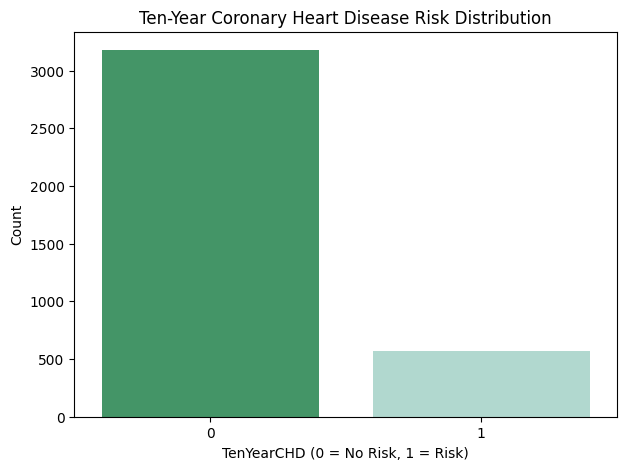

In [6]:
#Exploratory Data Analysis of Heart Disease Dataset
#In Exploratory Data Analysis (EDA) we perform EDA on the heart disease dataset to understand and gain insights
#into the dataset before building a predictive model for heart disease.#Ten Year's CHD Record of all the patients 
#available in the dataset:sns.countplot(x='TenYearCHD', data=disease_df, palettte="BuGn_r"): creates a count plot
#using Seaborn which visualizes the distribution of the values in the TenYearCHD column showing how many individuals 
#have heart disease (1) vs. how many don’t (0)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))
sns.countplot(
    x='TenYearCHD',
    data=disease_df,
    hue='TenYearCHD',       # map the same variable to hue
    palette="BuGn_r",       # your reverse blue-green palette
    legend=False            # hide redundant legend
)
plt.title("Ten-Year Coronary Heart Disease Risk Distribution")
plt.xlabel("TenYearCHD (0 = No Risk, 1 = Risk)")
plt.ylabel("Count")
plt.show()

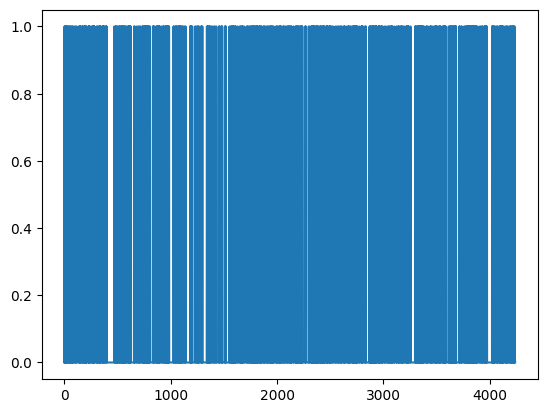

In [7]:
laste = disease_df['TenYearCHD'].plot()
plt.show(laste)

In [8]:
#Fitting Logistic Regression Model for Heart Disease Prediction
#We will create a simple logistic regression model for prediction.
#logreg=LogisticRegression(): This creates an instance of the LogisticRegression model.
#logreg.fit(X_train, y_train): This trains the logistic regression model using the training
#data (X_train for features and y_train for the target).#y_pred=logreg.predict(X_test): 
#This uses the trained logistic regression model to make predictions on the test set (X_test).
#The predicted values are stored in y_pred.
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score
print('Accuracy of the model is =', 
      accuracy_score(y_test, y_pred))

Accuracy of the model is = 0.8490230905861457


The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       951
           1       0.61      0.08      0.14       175

    accuracy                           0.85      1126
   macro avg       0.73      0.54      0.53      1126
weighted avg       0.82      0.85      0.80      1126



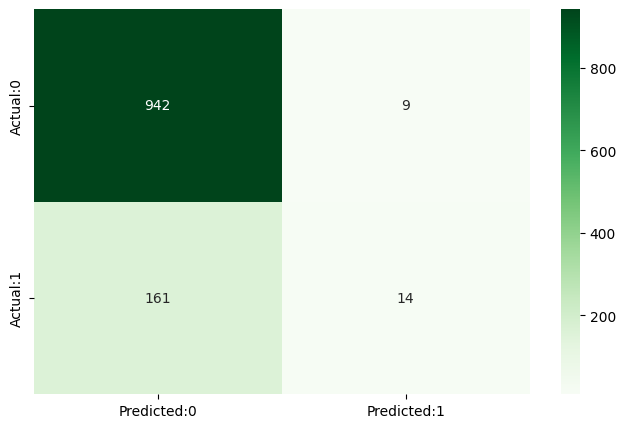

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
conf_matrix = pd.DataFrame(data = cm, 
                           columns = ['Predicted:0', 'Predicted:1'], 
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")
plt.show()